In [1]:
import os
from pathlib import Path
from typing import Literal

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import parallel_backend
from sklearn.base import ClassifierMixin
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    f1_score, 
    precision_score, 
    recall_score,
) 
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm_joblib import tqdm_joblib
from tqdm.notebook import tqdm

c:\Users\Mambo\Desktop\LLMs4LLMs\projects\SubsurfaceBreaks_DataScalingMethods-main\SubsurfaceBreaks_DataScalingMethods-main\.venv\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


# Config and Paths

In [2]:
INPUT_PATH = r"../../SubsurfaceBreaks-main/Broken_terrains_datasets"
# EXCLUDE_FILES = ["KSH", "params"]
REAL_DATA_FILE = "KSH_input_output_0.txt"

RANDOM_STATE = 42

SVM = "SVM"

SS_MODE: Literal[1, 2, 3] = 1

X_C_LOWER = 922000
X_C_UPPER = 923500
Y_C_LOWER = 249500
Y_C_UPPER = 251100

In [3]:
if SS_MODE == 2:
    raise ValueError(
        "SS_MODE == 2 is not suppported HERE anymore."
        "It leads to the data leakage."
        "Check 'ss_experiment_4_... .ipynb'"
        )

In [4]:
pd.set_option('display.max_columns', None)

np.random.seed(RANDOM_STATE)
random_state = np.random.RandomState(RANDOM_STATE)

## Load Data

In [5]:
files = os.listdir(INPUT_PATH)

# dfs = [
#     pd.read_csv(os.path.join(INPUT_PATH, file), decimal='.', sep=';') 
#     for file in files 
#     if file.endswith('.txt')
#     and not any(exclude in file for exclude in EXCLUDE_FILES)
# ]

dfs = [pd.read_csv(os.path.join(INPUT_PATH, str(file) + ".txt"), decimal='.', sep=';') for file in range(1000)]

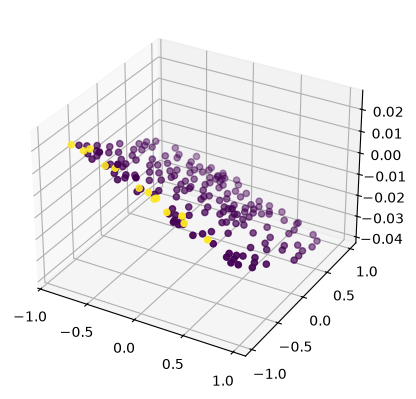

In [ ]:
df_0 = dfs[4]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# ax.scatter(df_0['X_C'], df_0['Y_C'], df_0["Z_C"])
ax.scatter(df_0['X_C'], df_0['Y_C'], df_0["Z_C"], c=df_0['Fault'], cmap='viridis')

In [7]:
df = pd.concat(
    dfs,
    ignore_index=True
)

In [8]:
df.describe()

,Dip_angle,Dip_direction,X_C,Y_C,Z_C,X_N,Y_N,Z_N,X_D,Y_D,Z_D,EuclideanNeighbor1_N,EuclideanNeighbor2_N,EuclideanNeighbor3_N,AngleNeighbor1_N,AngleNeighbor2_N,AngleNeighbor3_N,CosineNeighbor1_N,CosineNeighbor2_N,CosineNeighbor3_N,EuclideanNeighbor1_D,EuclideanNeighbor2_D,EuclideanNeighbor3_D,AngleNeighbor1_D,AngleNeighbor2_D,AngleNeighbor3_D,CosineNeighbor1_D,CosineNeighbor2_D,CosineNeighbor3_D,n1_xn,n1_yn,n1_zn,n2_xn,n2_yn,n2_zn,n3_xn,n3_yn,n3_zn,n1_xd,n1_yd,n1_zd,n2_xd,n2_yd,n2_zd,n3_xd,n3_yd,n3_zd,File_number,IDT1,IDT2,IDT3,Fault,DOC
count,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000,185980.000000
mean,1.686647,61.142806,-0.000569,0.002959,-0.003796,0.014695,0.014603,0.998450,0.608457,0.609351,-0.029108,-250.038731,-237.726712,-158.425096,-249.080416,-236.762541,-157.463730,-250.053833,-237.741871,-158.440295,-249.767773,-237.456678,-158.151274,-235.495863,-223.207262,-143.764478,-249.926776,-237.615497,-158.311933,-250.041363,-250.041235,-249.082036,-237.729411,-237.729520,-236.768803,-158.427536,-158.427665,-157.459020,-249.460797,-249.458528,-250.083623,-237.148350,-237.147702,-237.771565,-157.839927,-157.839614,-158.469627,499.615926,50.511136,50.492811,50.525067,-0.816937,0.774001
std,2.813648,60.988657,0.547986,0.548814,0.013758,0.032964,0.033867,0.020829,0.359357,0.355910,0.042609,1561.345620,1523.383734,1248.668076,1561.502821,1523.538119,1248.794619,1561.343201,1523.381367,1248.666146,1561.389070,1523.425932,1248.702889,1563.786209,1525.763799,1250.667479,1561.363588,1523.401129,1248.682483,1561.345198,1561.345219,1561.498839,1523.383312,1523.383295,1523.533228,1248.667765,1248.667749,1248.790660,1561.438218,1561.438580,1561.338430,1523.474035,1523.474135,1523.376733,1248.742376,1248.742414,1248.662424,288.668819,28.860122,28.781770,28.945715,0.576728,0.126374
min,0.027584,0.008351,-0.996607,-0.995801,-0.054644,-0.999872,-0.997614,0.003385,-0.999954,-0.999965,-0.999994,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.000000,1.000000,1.000000,1.000000,-1.000000,0.501172
25%,0.876864,32.591833,-0.472405,-0.470729,-0.012862,0.008373,0.008352,0.999527,0.478078,0.478890,-0.030747,0.001750,0.001765,0.001814,0.100240,0.101128,0.103940,0.000002,0.000002,0.000002,0.040188,0.039887,0.042042,2.300315,2.284175,2.407275,0.000808,0.000796,0.000884,0.007999,0.007981,0.999507,0.008000,0.007981,0.999509,0.008158,0.008127,0.999517,0.460149,0.463097,-0.031390,0.462378,0.462439,-0.031344,0.469176,0.468137,-0.031074,250.000000,25.000000,26.000000,25.000000,-1.000000,0.674247
50%,1.303270,47.514043,-0.001200,0.006279,-0.003735,0.013472,0.013566,0.999741,0.692470,0.689491,-0.022744,0.004562,0.004577,0.004666,0.261394,0.262227,0.267354,0.000010,0.000010,0.000011,0.125968,0.125900,0.128887,7.181595,7.172180,7.342230,0.007934,0.007925,0.008306,0.013155,0.013276,0.999733,0.013163,0.013283,0.999734,0.013309,0.013358,0.999737,0.683817,0.680688,-0.023103,0.683714

In [9]:
df

,Dip_angle,Dip_direction,X_C,Y_C,Z_C,X_N,Y_N,Z_N,X_D,Y_D,Z_D,X_C_Neighbor1,Y_C_Neighbor1,Z_C_Neighbor1,X_C_Neighbor2,Y_C_Neighbor2,Z_C_Neighbor2,X_C_Neighbor3,Y_C_Neighbor3,Z_C_Neighbor3,EuclideanNeighbor1_N,EuclideanNeighbor2_N,EuclideanNeighbor3_N,AngleNeighbor1_N,AngleNeighbor2_N,AngleNeighbor3_N,CosineNeighbor1_N,CosineNeighbor2_N,CosineNeighbor3_N,EuclideanNeighbor1_D,EuclideanNeighbor2_D,EuclideanNeighbor3_D,AngleNeighbor1_D,AngleNeighbor2_D,AngleNeighbor3_D,CosineNeighbor1_D,CosineNeighbor2_D,CosineNeighbor3_D,n1_xn,n1_yn,n1_zn,n2_xn,n2_yn,n2_zn,n3_xn,n3_yn,n3_zn,n1_xd,n1_yd,n1_zd,n2_xd,n2_yd,n2_zd,n3_xd,n3_yd,n3_zd,File_number,IDT1,IDT2,IDT3,Fault,DOC
0,1.556066,47.018229,-0.098949,0.446511,-0.020856,0.018513,0.019866,0.999631,0.681514,0.731301,-0.027155,-0.066766,0.561281,-0.023503,-0.237204,0.340819,-0.016412,0.012081,0.375976,-0.021316,0.005307,0.002287,0.003575,0.304043,0.131035,0.204844,1.407970e-05,0.000003,0.000006,0.140068,0.032647,0.131887,8.031870,1.87059,7.56208,0.009810,0.000533,0.008697,0.018017,0.014583,0.999731,0.016461,0.018859,0.999687,0.015626,0.021974,0.999636,0.777079,0.628976,-0.023180,0.657360,0.753161,-0.025033,0.579311,0.814660,-0.026963,0,26,39,78,-1,0.516929
1,1.573382,44.834329,0.187326,-0.737851,-0.001938,0.019471,0.019359,0.999623,0.708881,0.704793,-0.027457,0.135310,-0.808702,0.000499,0.427727,-0.806254,-0.004318,0.174544,-0.548305,-0.005460,0.001880,0.004645,0.001495,0.107730,0.266159,0.085670,1.767670e-06,0.000011,0.000001,0.032277,0.142818,0.052541,1.849400,8.18982,3.01074,0.000521,0.010198,0.001380,0.021288,0.019842,0.999576,0.014840,0.019711,0.999696,0.018665,0.020618,0.999613,0.731203,0.681538,-0.029101,0.601278,0.798659,-0.024673,0.670864,0.741059,-0.027812,0,92,22,87,-1,0.843997
2,4.400968,195.153984,0.909721,0.356969,-0.029901,-0.074067,-0.020060,0.997051,-0.962381,-0.260643,-0.076736,0.889179,0.217655,-0.032168,0.960052,0.493150,-0.028176,0.871308,0.509142,-0.032128,0.106846,0.168540,0.169198,6.124750,9.668120,9.705910,5.708060e-03,0.014203,0.014314,1.937210,1.967420,0.450850,28.790000,20.71050,26.05580,1.876390,1.935380,0.101633,0.023905,0.022504,0.999461,0.093802,-0.005111,0.995578,-0.230687,0.038956,0.972248,0.727724,0.685084,-0.032831,0.994103,-0.054165,-0.093941,-0.958675,0.161891,-0.233953,0,74,84,60,1,0.929419
3,1.398556,60.617343,-0.098386,0.126923,-0.014820,0.011975,0.021267,0.999702,0.490494,0.871103,-0.024407,-0.064006,0.069128,-0.014250,-0.096185,0.227978,-0.016786,-0.190714,0.116782,-0.013374,0.012803,0.013096,0.001810,0.733549,0.750351,0.103704,8.195520e-05,0.000086,0.000002,0.458461,0.381908,0.060965,26.503500,22.01690,3.49356,0.105093,0.072927,0.001858,0.023651,0.016016,0.999592,0.001701,0.013149,0.999912,0.013784,0.021326,0.999678,0.827670,0.560488,-0.028563,0.128282,0.991649,-0.013259,0.542660,0.839569,-0.025392,0,56,36,8,-1,0.858343
4,1.351324,47.106136,0.397915,0.461839,-0.029262,0.016051,0.017277,0.999722,0.680453,0.732412,-0.023583,0.537770,0.480156,-0.031819,0.304514,0.533891,-0.028933,0.381166,0.333187,-0.026476,0.000111,0.001773,0.005465,0.006374,0.101583,0.313096,6.187860e-09,0.000002,0.000015,0.003814,0.071786,0.071078,0.218508,4.11389,4.07331,0.000007,0.002577,0.002526,0.015941,0.017290,0.999723,0.016819,0.015679,0.999736,0.018010,0.022377,0.999587,0.677656,0.735003,-0.023517,0.731264,0.681707,-0.022993,0.626751,0.778690,-0.028725,0,59,43,4,-1,0.615843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185975,2.492114,67.986653,0.721384,-0.858808,0.005701,0.016298,0.040312,0.999054,0.374468,0.926220,-0.043482,0.717247,-0.838239,0.005381,0.749468,-0.877475,0.005577,0.843989,-0.870900,0.004101,0.047276,0.105431,0.007740,2.708980,6.043540,0.443474,1.117520e-03,0.005558,0.000030,1.456990,1.954560,0.131429,86.479000,24.47300,7.53576,1.061420,1.910160,0.008637,

## Filter Data

In [10]:
filtered_df=df[
    (df.X_C_Neighbor1!='undefined') 
    & (df.X_C_Neighbor2!='undefined')
    & (df.X_C_Neighbor3!='undefined') 
    & (df.Z_N!=0) 
    & (df.n1_zn!=0) 
    & (df.n2_zn!=0) 
    & (df.n3_zn!=0) 
    & (df.DOC<0.90)  
].reset_index(drop=True)

In [11]:
filtered_df.head(5)

,Dip_angle,Dip_direction,X_C,Y_C,Z_C,X_N,Y_N,Z_N,X_D,Y_D,Z_D,X_C_Neighbor1,Y_C_Neighbor1,Z_C_Neighbor1,X_C_Neighbor2,Y_C_Neighbor2,Z_C_Neighbor2,X_C_Neighbor3,Y_C_Neighbor3,Z_C_Neighbor3,EuclideanNeighbor1_N,EuclideanNeighbor2_N,EuclideanNeighbor3_N,AngleNeighbor1_N,AngleNeighbor2_N,AngleNeighbor3_N,CosineNeighbor1_N,CosineNeighbor2_N,CosineNeighbor3_N,EuclideanNeighbor1_D,EuclideanNeighbor2_D,EuclideanNeighbor3_D,AngleNeighbor1_D,AngleNeighbor2_D,AngleNeighbor3_D,CosineNeighbor1_D,CosineNeighbor2_D,CosineNeighbor3_D,n1_xn,n1_yn,n1_zn,n2_xn,n2_yn,n2_zn,n3_xn,n3_yn,n3_zn,n1_xd,n1_yd,n1_zd,n2_xd,n2_yd,n2_zd,n3_xd,n3_yd,n3_zd,File_number,IDT1,IDT2,IDT3,Fault,DOC
0,1.556066,47.018229,-0.098949,0.446511,-0.020856,0.018513,0.019866,0.999631,0.681514,0.731301,-0.027155,-0.066766,0.561281,-0.023503,-0.237204,0.340819,-0.016412,0.012081,0.375976,-0.021316,0.005307,0.002287,0.003575,0.304043,0.131035,0.204844,1.407970e-05,0.000003,0.000006,0.140068,0.032647,0.131887,8.031870,1.87059,7.56208,0.009810,0.000533,0.008697,0.018017,0.014583,0.999731,0.016461,0.018859,0.999687,0.015626,0.021974,0.999636,0.777079,0.628976,-0.023180,0.657360,0.753161,-0.025033,0.579311,0.814660,-0.026963,0,26,39,78,-1,0.516929
1,1.573382,44.834329,0.187326,-0.737851,-0.001938,0.019471,0.019359,0.999623,0.708881,0.704793,-0.027457,0.135310,-0.808702,0.000499,0.427727,-0.806254,-0.004318,0.174544,-0.548305,-0.005460,0.001880,0.004645,0.001495,0.107730,0.266159,0.085670,1.767670e-06,0.000011,0.000001,0.032277,0.142818,0.052541,1.849400,8.18982,3.01074,0.000521,0.010198,0.001380,0.021288,0.019842,0.999576,0.014840,0.019711,0.999696,0.018665,0.020618,0.999613,0.731203,0.681538,-0.029101,0.601278,0.798659,-0.024673,0.670864,0.741059,-0.027812,0,92,22,87,-1,0.843997
2,1.398556,60.617343,-0.098386,0.126923,-0.014820,0.011975,0.021267,0.999702,0.490494,0.871103,-0.024407,-0.064006,0.069128,-0.014250,-0.096185,0.227978,-0.016786,-0.190714,0.116782,-0.013374,0.012803,0.013096,0.001810,0.733549,0.750351,0.103704,8.195520e-05,0.000086,0.000002,0.458461,0.381908,0.060965,26.503500,22.01690,3.49356,0.105093,0.072927,0.001858,0.023651,0.016016,0.999592,0.001701,0.013149,0.999912,0.013784,0.021326,0.999678,0.827670,0.560488,-0.028563,0.128282,0.991649,-0.013259,0.542660,0.839569,-0.025392,0,56,36,8,-1,0.858343
3,1.351324,47.106136,0.397915,0.461839,-0.029262,0.016051,0.017277,0.999722,0.680453,0.732412,-0.023583,0.537770,0.480156,-0.031819,0.304514,0.533891,-0.028933,0.381166,0.333187,-0.026476,0.000111,0.001773,0.005465,0.006374,0.101583,0.313096,6.187860e-09,0.000002,0.000015,0.003814,0.071786,0.071078,0.218508,4.11389,4.07331,0.000007,0.002577,0.002526,0.015941,0.017290,0.999723,0.016819,0.015679,0.999736,0.018010,0.022377,0.999587,0.677656,0.735003,-0.023517,0.731264,0.681707,-0.022993,0.626751,0.778690,-0.028725,0,59,43,4,-1,0.615843
4,1.096262,48.845084,0.165883,0.519810,-0.026550,0.012591,0.014405,0.999817,0.657977,0.752795,-0.019132,0.304514,0.533891,-0.028933,0.140084,0.579276,-0.027208,0.116050,0.498138,-0.025563,0.004416,0.005747,0.003115,0.253029,0.329299,0.178449,9.751390e-06,0.000017,0.000005,0.102174,0.219604,0.025869,5.856700,12.60780,1.48221,0.005220,0.024113,0.000335,0.016819,0.015679,0.999736,0.010809,0.019869,0.999744,0.014176,0.017085,0.999754,0.731264,0.681707,-0.022993,0.477741,0.878210,-0.022618,0.638380,0.769401,-0.022201,0,86,59,38,-1,0.700072


In [12]:
filtered_df.describe()

,Dip_angle,Dip_direction,X_C,Y_C,Z_C,X_N,Y_N,Z_N,X_D,Y_D,Z_D,EuclideanNeighbor1_N,EuclideanNeighbor2_N,EuclideanNeighbor3_N,AngleNeighbor1_N,AngleNeighbor2_N,AngleNeighbor3_N,CosineNeighbor1_N,CosineNeighbor2_N,CosineNeighbor3_N,EuclideanNeighbor1_D,EuclideanNeighbor2_D,EuclideanNeighbor3_D,AngleNeighbor1_D,AngleNeighbor2_D,AngleNeighbor3_D,CosineNeighbor1_D,CosineNeighbor2_D,CosineNeighbor3_D,n1_xn,n1_yn,n1_zn,n2_xn,n2_yn,n2_zn,n3_xn,n3_yn,n3_zn,n1_xd,n1_yd,n1_zd,n2_xd,n2_yd,n2_zd,n3_xd,n3_yd,n3_zd,File_number,IDT1,IDT2,IDT3,Fault,DOC
count,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,1.452970e+05,1.452970e+05,1.452970e+05,1.452970e+05,145297.000000,1.452970e+05,1.452970e+05,1.452970e+05,1.452970e+05,1.452970e+05,1.452970e+05,1.452970e+05,145297.000000,145297.000000,145297.000000,1.452970e+05,1.452970e+05,1.452970e+05,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000,145297.000000
mean,1.442136,55.773712,-0.000865,0.002930,-0.003803,0.014657,0.014747,0.999515,0.631717,0.631074,-0.025157,1.206251e-02,1.210229e-02,1.186949e-02,6.929747e-01,0.695576,6.817664e-01,6.818073e-04,7.159921e-04,6.260815e-04,2.453180e-01,2.439521e-01,2.444365e-01,12.674585,12.647335,12.629517,9.804193e-02,9.681110e-02,9.704863e-02,0.014639,0.014735,0.999089,0.014661,0.014613,0.999057,0.014673,0.014627,0.999145,0.619157,0.618882,-0.026961,0.617762,0.618185,-0.027019,0.619221,0.619616,-0.026744,499.600061,50.550927,50.497952,50.508875,-0.829164,0.729410
std,1.054245,51.244538,0.515682,0.517055,0.013098,0.016622,0.016084,0.001828,0.319682,0.315464,0.018287,3.490156e-02,3.585426e-02,3.333594e-02,2.047747e+00,2.113739,1.958398e+00,1.219939e-02,1.365837e-02,1.189661e-02,3.686515e-01,3.662110e-01,3.665365e-01,16.855024,16.822628,16.710052,3.003995e-01,2.972869e-01,2.986424e-01,0.024956,0.024823,0.012312,0.024993,0.025438,0.013574,0.024149,0.023613,0.011824,0.342093,0.339017,0.030717,0.343659,0.341200,0.031148,0.342709,0.337081,0.029237,288.542289,28.841563,28.783799,28.957598,0.559008,0.098364
min,0.027584,0.008351,-0.978262,-0.984830,-0.052443,-0.606558,-0.498776,0.704785,-0.999921,-0.999932,-0.709421,1.169510e-08,2.933050e-08,1.169510e-08,8.537740e-07,0.000002,8.537740e-07,1.110220e-16,4.440890e-16,1.110220e-16,2.158670e-07,2.158670e-07,2.274640e-07,0.000012,0.000012,0.000013,2.320370e-14,2.320370e-14,2.586820e-14,-0.980641,-0.997614,0.010296,-0.999872,-0.994897,0.006959,-0.997208,-0.993271,0.003385,-0.999954,-0.999965,-0.999947,-0.999954,-0.999911,-0.999976,-0.999921,-0.999965,-0.999994,0.000000,1.000000,1.000000,1.000000,-1.000000,0.501172
25%,0.867971,32.438662,-0.442681,-0.440567,-0.012376,0.008675,0.008618,0.999557,0.499290,0.498213,-0.029765,1.686520e-03,1.686730e-03,1.682700e-03,9.663040e-02,0.096643,9.641150e-02,1.422170e-06,1.422530e-06,1.415740e-06,3.881810e-02,3.850510e-02,3.905100e-02,2.223350,2.205550,2.236210,7.534220e-04,7.413200e-04,7.624900e-04,0.008501,0.008450,0.999542,0.008463,0.008446,0.999542,0.008489,0.008440,0.999542,0.487803,0.488032,-0.030275,0.487415,0.488732,-0.030262,0.487920,0.487498,-0.030253,250.000000,26.000000,26.000000,25.000000,-1.000000,0.652485
50%,1.277471,46.475332,-0.002034,0.006467,-0.003712,0.013527,0.013580,0.999751,0.699415,0.693907,-0.022294,4.067430e-03,4.069360e-03,4.075350e-03,2.330470e-01,0.233157,2.335010e-01,8.271980e-06,8.279830e-06,8.304260e-06,1.125590e-01,1.122830e-01,1.126240e-01,6.421950,6.408940,6.424380,6.334760e-03,6.303760e-03,6.342130e-03,0.013508,0.013569,0.999746,0.013458,0.013573,0.999747,0.013496,0.013542,0.999746,0.696744,0.690731,-0.022521,0.695162,0.691963,-0.022515,0.696254,0.691360,-0.022521,500.000000,51.000000,5

In [13]:
filtered_df

,Dip_angle,Dip_direction,X_C,Y_C,Z_C,X_N,Y_N,Z_N,X_D,Y_D,Z_D,X_C_Neighbor1,Y_C_Neighbor1,Z_C_Neighbor1,X_C_Neighbor2,Y_C_Neighbor2,Z_C_Neighbor2,X_C_Neighbor3,Y_C_Neighbor3,Z_C_Neighbor3,EuclideanNeighbor1_N,EuclideanNeighbor2_N,EuclideanNeighbor3_N,AngleNeighbor1_N,AngleNeighbor2_N,AngleNeighbor3_N,CosineNeighbor1_N,CosineNeighbor2_N,CosineNeighbor3_N,EuclideanNeighbor1_D,EuclideanNeighbor2_D,EuclideanNeighbor3_D,AngleNeighbor1_D,AngleNeighbor2_D,AngleNeighbor3_D,CosineNeighbor1_D,CosineNeighbor2_D,CosineNeighbor3_D,n1_xn,n1_yn,n1_zn,n2_xn,n2_yn,n2_zn,n3_xn,n3_yn,n3_zn,n1_xd,n1_yd,n1_zd,n2_xd,n2_yd,n2_zd,n3_xd,n3_yd,n3_zd,File_number,IDT1,IDT2,IDT3,Fault,DOC
0,1.556066,47.018229,-0.098949,0.446511,-0.020856,0.018513,0.019866,0.999631,0.681514,0.731301,-0.027155,-0.066766,0.561281,-0.023503,-0.237204,0.340819,-0.016412,0.012081,0.375976,-0.021316,0.005307,0.002287,0.003575,0.304043,0.131035,0.204844,1.407970e-05,2.615160e-06,6.391040e-06,0.140068,0.032647,0.131887,8.031870,1.870590,7.562080,0.009810,0.000533,0.008697,0.018017,0.014583,0.999731,0.016461,0.018859,0.999687,0.015626,0.021974,0.999636,0.777079,0.628976,-0.023180,0.657360,0.753161,-0.025033,0.579311,0.814660,-0.026963,0,26,39,78,-1,0.516929
1,1.573382,44.834329,0.187326,-0.737851,-0.001938,0.019471,0.019359,0.999623,0.708881,0.704793,-0.027457,0.135310,-0.808702,0.000499,0.427727,-0.806254,-0.004318,0.174544,-0.548305,-0.005460,0.001880,0.004645,0.001495,0.107730,0.266159,0.085670,1.767670e-06,1.078960e-05,1.117840e-06,0.032277,0.142818,0.052541,1.849400,8.189820,3.010740,0.000521,0.010198,0.001380,0.021288,0.019842,0.999576,0.014840,0.019711,0.999696,0.018665,0.020618,0.999613,0.731203,0.681538,-0.029101,0.601278,0.798659,-0.024673,0.670864,0.741059,-0.027812,0,92,22,87,-1,0.843997
2,1.398556,60.617343,-0.098386,0.126923,-0.014820,0.011975,0.021267,0.999702,0.490494,0.871103,-0.024407,-0.064006,0.069128,-0.014250,-0.096185,0.227978,-0.016786,-0.190714,0.116782,-0.013374,0.012803,0.013096,0.001810,0.733549,0.750351,0.103704,8.195520e-05,8.575270e-05,1.637990e-06,0.458461,0.381908,0.060965,26.503500,22.016900,3.493560,0.105093,0.072927,0.001858,0.023651,0.016016,0.999592,0.001701,0.013149,0.999912,0.013784,0.021326,0.999678,0.827670,0.560488,-0.028563,0.128282,0.991649,-0.013259,0.542660,0.839569,-0.025392,0,56,36,8,-1,0.858343
3,1.351324,47.106136,0.397915,0.461839,-0.029262,0.016051,0.017277,0.999722,0.680453,0.732412,-0.023583,0.537770,0.480156,-0.031819,0.304514,0.533891,-0.028933,0.381166,0.333187,-0.026476,0.000111,0.001773,0.005465,0.006374,0.101583,0.313096,6.187860e-09,1.571680e-06,1.493060e-05,0.003814,0.071786,0.071078,0.218508,4.113890,4.073310,0.000007,0.002577,0.002526,0.015941,0.017290,0.999723,0.016819,0.015679,0.999736,0.018010,0.022377,0.999587,0.677656,0.735003,-0.023517,0.731264,0.681707,-0.022993,0.626751,0.778690,-0.028725,0,59,43,4,-1,0.615843
4,1.096262,48.845084,0.165883,0.519810,-0.026550,0.012591,0.014405,0.999817,0.657977,0.752795,-0.019132,0.304514,0.533891,-0.028933,0.140084,0.579276,-0.027208,0.116050,0.498138,-0.025563,0.004416,0.005747,0.003115,0.253029,0.329299,0.178449,9.751390e-06,1.651600e-05,4.850100e-06,0.102174,0.219604,0.025869,5.856700,12.607800,1.482210,0.005220,0.024113,0.000335,0.016819,0.015679,0.999736,0.010809,0.019869,0.999744,0.014176,0.017085,0.999754,0.731264,0.681707,-0.022993,0.477741,0.878210,-0.022618,0.638380,0.769401,-0.022201,0,86,59,38,-1,0.700072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145292,1.480051,44.029217,0.706312,-0.426848,-0.001620,0.018571,0.017952,0.999666,0.718746,0.694793,-0.025829,0.542834,-0.450672,0.001355,0.744998,-0.517993,-0.000641,0.746541,-0.302151,-0.004798,0.005746,0.001142,0.002879,0.329228,0.065413,0.164942,1.650880e-05,6.517170e-07,4.143700e-06,0.175741,0.043839,0.083704,10.

## Sort Data

In [14]:
euclidean_n = ['EuclideanNeighbor1_N', 'EuclideanNeighbor2_N','EuclideanNeighbor3_N']
euclidean_d = ['EuclideanNeighbor1_D', 'EuclideanNeighbor2_D','EuclideanNeighbor3_D']
cosine_n = ['CosineNeighbor1_N', 'CosineNeighbor2_N','CosineNeighbor3_N']
cosine_d = ['CosineNeighbor1_D', 'CosineNeighbor2_D','CosineNeighbor3_D']
angle_n = ['AngleNeighbor1_N', 'AngleNeighbor2_N','AngleNeighbor3_N']
angle_d = ['AngleNeighbor1_D', 'AngleNeighbor2_D','AngleNeighbor3_D']

euclidean_n_sorted = ['Euclidean_N_Max', 'Euclidean_N_Min', 'Euclidean_N_Intermediate']
euclidean_d_sorted = ['Euclidean_D_Max', 'Euclidean_D_Min', 'Euclidean_D_Intermediate']
cosine_n_sorted = ['Cosine_N_Max', 'Cosine_N_Min', 'Cosine_N_Intermediate']
cosine_d_sorted = ['Cosine_D_Max', 'Cosine_D_Min', 'Cosine_D_Intermediate']
angle_n_sorted = ['Angle_N_Max', 'Angle_N_Min', 'Angle_N_Intermediate']
angle_d_sorted = ['Angle_D_Max', 'Angle_D_Min', 'Angle_D_Intermediate']

sorting_pairs = [
    (euclidean_n, euclidean_n_sorted),
    (euclidean_d, euclidean_d_sorted),
    (cosine_n, cosine_n_sorted),
    (cosine_d, cosine_d_sorted),
    (angle_n, angle_n_sorted),
    (angle_d, angle_d_sorted)
]

In [15]:
def sort_values(row: pd.Series, output_columns: list) -> pd.Series:
    """
    Sort Neighbor values in descending order and return a Series with max, intermediate, and min values.

    Parameters
    ----------
    row : pd.Series
        A pandas Series containing Neighbor values.
    output_columns : list
        A list of column names for the output Series.
        Maximum value, intermediate value, minimum value.

    Returns
    -------
    pd.Series
        A pandas Series with the maximum, intermediate, and minimum values.
    """
    max_val = row.max()
    min_val = row.min()
    remaining_val = row.sum() - max_val - min_val
    return pd.Series([max_val, min_val, remaining_val], index=output_columns)

In [16]:
sorted_dfs = [
    filtered_df[list(cols)].apply(sort_values, axis=1, output_columns=list(sorted_cols))
    for cols, sorted_cols in sorting_pairs
]

## Concatenate Synthetic Data

In [17]:
sorted_df=pd.concat([
    filtered_df[['X_N']],
    filtered_df[['Y_N']],
    filtered_df[['Z_N']],
    filtered_df[['X_D']],
    filtered_df[['Y_D']],
    filtered_df[['Z_D']],   
    *sorted_dfs,
    filtered_df[['File_number']],
    filtered_df[['Fault']]   
    ], 
    axis=1
)
sorted_df.shape

(145297, 26)

In [18]:
sorted_df

,X_N,Y_N,Z_N,X_D,Y_D,Z_D,Euclidean_N_Max,Euclidean_N_Min,Euclidean_N_Intermediate,Euclidean_D_Max,Euclidean_D_Min,Euclidean_D_Intermediate,Cosine_N_Max,Cosine_N_Min,Cosine_N_Intermediate,Cosine_D_Max,Cosine_D_Min,Cosine_D_Intermediate,Angle_N_Max,Angle_N_Min,Angle_N_Intermediate,Angle_D_Max,Angle_D_Min,Angle_D_Intermediate,File_number,Fault
0,0.018513,0.019866,0.999631,0.681514,0.731301,-0.027155,0.005307,0.002287,0.003575,0.140068,0.032647,0.131887,0.000014,2.615160e-06,6.391040e-06,0.009810,0.000533,0.008697,0.304043,0.131035,0.204844,8.03187,1.870590,7.562080,0,-1
1,0.019471,0.019359,0.999623,0.708881,0.704793,-0.027457,0.004645,0.001495,0.001880,0.142818,0.032277,0.052541,0.000011,1.117840e-06,1.767670e-06,0.010198,0.000521,0.001380,0.266159,0.085670,0.107730,8.18982,1.849400,3.010740,0,-1
2,0.011975,0.021267,0.999702,0.490494,0.871103,-0.024407,0.013096,0.001810,0.012803,0.458461,0.060965,0.381908,0.000086,1.637990e-06,8.195520e-05,0.105093,0.001858,0.072927,0.750351,0.103704,0.733549,26.50350,3.493560,22.016900,0,-1
3,0.016051,0.017277,0.999722,0.680453,0.732412,-0.023583,0.005465,0.000111,0.001773,0.071786,0.003814,0.071078,0.000015,6.187860e-09,1.571680e-06,0.002577,0.000007,0.002526,0.313096,0.006374,0.101583,4.11389,0.218508,4.073310,0,-1
4,0.012591,0.014405,0.999817,0.657977,0.752795,-0.019132,0.005747,0.003115,0.004416,0.219604,0.025869,0.102174,0.000017,4.850100e-06,9.751390e-06,0.024113,0.000335,0.005220,0.329299,0.178449,0.253029,12.60780,1.482210,5.856700,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145292,0.018571,0.017952,0.999666,0.718746,0.694793,-0.025829,0.005746,0.001142,0.002879,0.175741,0.043839,0.083704,0.000017,6.517170e-07,4.143700e-06,0.015442,0.000961,0.003503,0.329228,0.065413,0.164942,10.08220,2.511980,4.797280,999,-1
145293,0.014677,0.016077,0.999763,0.674064,0.738352,-0.021768,0.002349,0.000310,0.001286,0.103480,0.007196,0.048888,0.000003,4.799320e-08,8.275330e-07,0.005354,0.000026,0.001195,0.134567,0.017751,0.073711,5.93162,0.412318,2.801340,999,-1
145294,0.014610,0.015774,0.999769,0.679362,0.733489,-0.021501,0.004458,0.000310,0.002702,0.121874,0.007196,0.012214,0.000010,4.799320e-08,3.650280e-06,0.007427,0.000026,0.000075,0.255419,0.017751,0.154811,6.98718,0.412318,0.699844,999,-1
145295,0.023838,0.042045,0.998831,0.492636,0.868892,-0.048333,0.060758,0.007740,0.016334,1.998230,0.131429,0.308138,0.001846,2.995430e-05,1.334040e-04,1.996470,0.008637,0.047475,3.481740,0.443474,0.935895,17.72560,4.817980,7.535760,999,-1


## Prepare datasets for modelling

In [19]:
if SS_MODE == 2:
    standardized_df = sorted_df.copy()
    scaler_2_A = StandardScaler()
    file_numbers = standardized_df["File_number"].unique()

    for file_number in file_numbers:
        file_mask = standardized_df["File_number"] == file_number
        standardized_df.loc[
            file_mask,
            standardized_df.columns.difference(["File_number", "Fault"]),
        ] = scaler_2_A.fit_transform(
            standardized_df.loc[
                file_mask,
                standardized_df.columns.difference(["File_number", "Fault"]),
            ]
    )
        
    df_for_downsampling = standardized_df.copy()
else:
    df_for_downsampling = sorted_df.copy()

In [20]:
class_count_0, class_count_1 = df_for_downsampling['Fault'].value_counts()
class_0 = df_for_downsampling[df_for_downsampling['Fault'] == -1]
class_1 = df_for_downsampling[df_for_downsampling['Fault'] == 1]# print the shape of the class
print('class 0:', class_0.shape)
print('class 1:', class_1.shape)

class_0_under = class_0.sample(class_count_1, random_state=RANDOM_STATE)

undersampled_df= pd.concat([class_0_under, class_1], axis=0)
undersampled_df.shape  

class 0: (132886, 26)
class 1: (12411, 26)


(24822, 26)

In [21]:
X = undersampled_df.drop(columns=['Fault', 'File_number'])
y = undersampled_df['Fault']
y[y == -1] = 0  # Change labels from -1, 1 to 0, 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

C:\Users\Mambo\AppData\Local\Temp\ipykernel_21108\2204962863.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[y == -1] = 0  # Change labels from -1, 1 to 0, 1


In [22]:
if SS_MODE == 1:
    scaler_1_A = StandardScaler()
    X_train = scaler_1_A.fit_transform(X_train)
    
    scaler_1_B = StandardScaler()
    X_test = scaler_1_B.fit_transform(X_test)

if SS_MODE == 3:
    scaler_3 = StandardScaler()
    X_train = scaler_3.fit_transform(X_train)
    X_test = scaler_3.transform(X_test)
    

## Initial Modelling

In [23]:
models = {}
models[SVM] = SVC(kernel="rbf", C=0.05, random_state=RANDOM_STATE)

In [24]:
accuracy, precision, recall, confusion, classification_rep, f1 = {}, {}, {}, {}, {}, {}

for key in models.keys():
    
    # Fit the classifier
    models[key].fit(X_train, y_train)
    
    # Make predictions
    predictions = models[key].predict(X_test)
    
    # Calculate metrics
    accuracy[key] = accuracy_score(y_test, predictions)
    precision[key] = precision_score(y_test, predictions)
    recall[key] = recall_score(y_test, predictions)
    f1[key] = f1_score(y_test, predictions)
    confusion[key]=confusion_matrix(y_test, predictions)
    classification_rep[key]=classification_report(y_test, predictions, target_names=['homocline', 'Fault'])

In [25]:
def print_metrics(model: str) -> None:
    print(f"Metrics for {model}:")
    print(f"Accuracy: {accuracy[model]:.4f}")
    print(f"Precision: {precision[model]:.4f}")
    print(f"Recall: {recall[model]:.4f}")
    print(f"F1 Score: {f1[model]:.4f}")
    print(f"Confusion Matrix:\n{confusion[model]}")
    tn, fp, fn, tp = confusion[model].ravel()
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Classification Report:\n{classification_rep[model]}")

In [26]:
for model in models.keys():
    print_metrics(model)
    print("================")

Metrics for SVM:
Accuracy: 0.9410
Precision: 0.9586
Recall: 0.9214
F1 Score: 0.9396
Confusion Matrix:
[[2993  123]
 [ 243 2847]]
TN: 2993, FP: 123, FN: 243, TP: 2847
Classification Report:
              precision    recall  f1-score   support

   homocline       0.92      0.96      0.94      3116
       Fault       0.96      0.92      0.94      3090

    accuracy                           0.94      6206
   macro avg       0.94      0.94      0.94      6206
weighted avg       0.94      0.94      0.94      6206



## Hyperparameter Tuning

In [27]:
def grid_search(model: ClassifierMixin, param_grid: dict, scoring: str, cv: int=5) -> ClassifierMixin:
    """
    Perform grid search to find the best hyperparameters for a given model.

    Parameters
    ----------
    model : ClassifierMixin
        The machine learning model to be optimized.
    param_grid : dict
        A dictionary where keys are hyperparameter names and values are lists of possible values.
    scoring : str
        The scoring metric to optimize (e.g., 'f1', 'accuracy').
    cv : int, optional
        The number of cross-validation folds (default is 5).

    Returns
    -------
    ClassifierMixin
        The model with the best found hyperparameters.
    """
    grid_search = GridSearchCV(model, param_grid, scoring=scoring, cv=cv, n_jobs=-1, refit=True, verbose=True)
    with parallel_backend('loky'):
        with tqdm_joblib(tqdm(desc="GridSearch Progress")):
            grid_search.fit(X_train, y_train)
    print(f"Best parameters for {model.__class__.__name__}: {grid_search.best_params_}")
    return grid_search.best_estimator_

In [28]:
param_grid = {}

param_grid[SVM]= {
    'C': [0.1, 1, 10, 100, 1000],  
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
    'kernel': ['rbf', 'linear'],
}  

In [29]:
models_tuning = {}

#models_tuning[SVM] = grid_search(SVC(random_state=RANDOM_STATE), param_grid[SVM], scoring='f1')
models_tuning[SVM] = SVC(kernel="rbf", C=10, gamma=0.1, random_state=RANDOM_STATE)

In [30]:
accuracy_tuning, precision_tuning, recall_tuning, confusion_tuning, classification_rep_tuning, f1_tuning = {}, {}, {}, {}, {}, {}

In [31]:
for key in models_tuning.keys():
    
    # Fit the classifier
    models_tuning[key].fit(X_train, y_train)
    
    # Make predictions
    predictions_tuning = models_tuning[key].predict(X_test)
    
    # Calculate metrics
    accuracy_tuning[key] = accuracy_score(y_test, predictions_tuning)
    precision_tuning[key] = precision_score(y_test, predictions_tuning)
    recall_tuning[key] = recall_score(y_test, predictions_tuning)
    f1_tuning[key] = f1_score(y_test, predictions_tuning)
    confusion_tuning[key]=confusion_matrix(y_test, predictions_tuning)
    classification_rep_tuning[key]=classification_report(y_test, predictions_tuning, target_names=['homocline', 'Fault'])


In [32]:
def print_metrics_tuning(model: str) -> None:
    print(f"Metrics for {model} after tuning:")
    print("Model parameters:", models_tuning[model].get_params())
    print(f"Accuracy: {accuracy_tuning[model]:.4f}")
    print(f"Precision: {precision_tuning[model]:.4f}")
    print(f"Recall: {recall_tuning[model]:.4f}")
    print(f"F1 Score: {f1_tuning[model]:.4f}")
    print(f"Confusion Matrix:\n{confusion_tuning[model]}")
    tn, fp, fn, tp = confusion_tuning[model].ravel()
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Classification Report:\n{classification_rep_tuning[model]}")

In [33]:
for model in models_tuning.keys():
    print_metrics_tuning(model)
    print("================")

Metrics for SVM after tuning:
Model parameters: {'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.1, 'kernel': 'rbf', 'max_iter': -1, 'probability': 'deprecated', 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
Accuracy: 0.9521
Precision: 0.9562
Recall: 0.9472
F1 Score: 0.9517
Confusion Matrix:
[[2982  134]
 [ 163 2927]]
TN: 2982, FP: 134, FN: 163, TP: 2927
Classification Report:
              precision    recall  f1-score   support

   homocline       0.95      0.96      0.95      3116
       Fault       0.96      0.95      0.95      3090

    accuracy                           0.95      6206
   macro avg       0.95      0.95      0.95      6206
weighted avg       0.95      0.95      0.95      6206



## Prepare real data

In [34]:
real_raw_df = pd.read_csv(INPUT_PATH + "/" + REAL_DATA_FILE, decimal=".", sep=";")
real_raw_df.shape

(1603, 60)

In [35]:
real_raw_df

,Dip_ang,Dip_dir,X_C,Y_C,Z_C,X_N,Y_N,Z_N,X_D,Y_D,Z_D,X_C_Neighbor1,Y_C_Neighbor1,Z_C_Neighbor1,X_C_Neighbor2,Y_C_Neighbor2,Z_C_Neighbor2,X_C_Neighbor3,Y_C_Neighbor3,Z_C_Neighbor3,EuclideanNeighbor1_N,EuclideanNeighbor2_N,EuclideanNeighbor3_N,AngleNeighbor1_N,AngleNeighbor2_N,AngleNeighbor3_N,CosineNeighbor1_N,CosineNeighbor2_N,CosineNeighbor3_N,EuclideanNeighbor1_D,EuclideanNeighbor2_D,EuclideanNeighbor3_D,AngleNeighbor1_D,AngleNeighbor2_D,AngleNeighbor3_D,CosineNeighbor1_D,CosineNeighbor2_D,CosineNeighbor3_D,n1_xn,n1_yn,n1_zn,n2_xn,n2_yn,n2_zn,n3_xn,n3_yn,n3_zn,n1_xd,n1_yd,n1_zd,n2_xd,n2_yd,n2_zd,n3_xd,n3_yd,n3_zd,IDT1,IDT2,IDT3,DOC
0,1.159130,46.169060,919729.743333,253500.996667,222.526667,0.014009,0.014593,0.999795,0.692391,0.721239,-0.020229,919844.566667,253407.796667,222.176667,919730.636667,253647.726667,218.603333,919586.153333,253439.170000,225.696667,0.001318,0.020979,0.003590,0.075508,1.202043,0.205697,0.000001,0.000220,0.000006,0.063257,0.453247,0.014737,3.624989,26.196732,0.844355,0.002001,0.102716,0.000109,0.015108,0.013865,0.999790,0.011252,0.035385,0.999310,0.016729,0.016935,0.999717,0.736611,0.676006,-0.020505,0.302840,0.952318,-0.037131,0.702578,0.711208,-0.023805,58,66,82,0.605231
1,0.384032,41.407344,922129.150000,248336.643333,247.466667,0.005027,0.004433,0.999978,0.750009,0.661393,-0.006703,922054.776667,248304.790000,247.920000,922133.513333,248274.283333,247.926667,922211.780000,248414.033333,246.220000,0.001702,0.010964,0.008716,0.097490,0.628212,0.499389,0.000001,0.000060,0.000038,0.246913,1.036992,0.022274,14.183271,62.462844,1.276241,0.030483,0.537676,0.000248,0.003421,0.004994,0.999982,-0.002952,0.011953,0.999924,0.011769,0.009957,0.999881,0.565088,0.825008,-0.006053,-0.239745,0.970758,-0.012312,0.763336,0.645817,-0.015416,501,488,469,0.786498
2,1.990172,94.352276,921097.226667,250946.403333,222.926667,-0.002635,0.034628,0.999397,-0.075843,0.996515,-0.034728,921088.526667,251054.406667,220.230000,921053.113333,250875.746667,225.156667,921154.753333,250889.306667,225.023333,0.024644,0.005648,0.000826,1.412057,0.323623,0.047332,0.000304,0.000016,0.000000,0.114003,0.162672,0.021516,6.535435,9.330701,1.232784,0.006498,0.013231,0.000231,-0.001896,0.010001,0.999948,-0.008205,0.033686,0.999399,-0.001870,0.034318,0.999409,-0.186278,0.982444,-0.010179,-0.236503,0.971012,-0.034671,-0.054377,0.997929,-0.034369,268,278,260,0.687838
3,1.832122,43.287073,922932.003333,249384.803333,227.776667,0.023273,0.021921,0.999489,0.727555,0.685304,-0.031971,922925.390000,249516.533333,225.133333,922855.463333,249318.230000,231.076667,923007.986667,249337.320000,226.940000,0.001446,0.001257,0.004529,0.082871,0.072039,0.259501,0.000001,0.000001,0.000010,0.033898,0.006834,0.114302,1.942316,0.391562,6.552593,0.000575,0.000023,0.006532,0.023270,0.020475,0.999520,0.024326,0.022607,0.999448,0.027604,0.020600,0.999407,0.750389,0.660269,-0.030995,0.732118,0.680368,-0.033209,0.800962,0.597723,-0.034443,667,677,640,0.597122
4,1.180099,36.660156,920497.100000,251283.926667,239.206667,0.016521,0.012297,0.999788,0.802021,0.596941,-0.020595,920445.773333,251286.356667,240.006667,920528.076667,251230.583333,237.296667,920547.873333,251356.440000,237.380000,0.000715,0.049476,0.002360,0.040954,2.835044,0.135230,0.000000,0.001224,0.000003,0.032876,1.174739,0.002499,1.883723,71.941106,0.143173,0.000540,0.690006,0.000003,0.015920,0.012684,0.999793,0.042262,-0.029941,0.998658,0.018425,0.013690,0.999737,0.781965,0.622989,-0.020355,0.814878,-0.577313,-0.051793,0.802470,0.596251,-0.022955,190,186,176,0.727719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1598,3.723528,21.021905,923029.516667,248126.393333,197.973333,0.060620,0.023296,0.997889,0.931473,0.357968,-0.064942,922857.400000,248021.540000,203.403333,923099.490000,248183.093333,191.970000,92291

In [36]:
real_raw_df.describe()

,Dip_ang,Dip_dir,X_C,Y_C,Z_C,X_N,Y_N,Z_N,X_D,Y_D,Z_D,EuclideanNeighbor1_N,EuclideanNeighbor2_N,EuclideanNeighbor3_N,AngleNeighbor1_N,AngleNeighbor2_N,AngleNeighbor3_N,CosineNeighbor1_N,CosineNeighbor2_N,CosineNeighbor3_N,EuclideanNeighbor1_D,EuclideanNeighbor2_D,EuclideanNeighbor3_D,AngleNeighbor1_D,AngleNeighbor2_D,AngleNeighbor3_D,CosineNeighbor1_D,CosineNeighbor2_D,CosineNeighbor3_D,n1_xn,n1_yn,n1_zn,n2_xn,n2_yn,n2_zn,n3_xn,n3_yn,n3_zn,n1_xd,n1_yd,n1_zd,n2_xd,n2_yd,n2_zd,n3_xd,n3_yd,n3_zd,IDT1,IDT2,IDT3,DOC
count,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000
mean,3.416009,131.897406,921674.740133,251595.655775,210.919214,0.014772,0.009953,0.993740,0.305663,0.371633,-0.058191,-12.418799,-43.608434,-37.368440,-9.310083,-40.576186,-34.094733,-12.466128,-43.655516,-37.418233,-11.800585,-43.003670,-36.754951,18.232364,-12.676012,-5.959469,-12.063444,-43.269302,-37.025372,-12.462804,-12.465521,-11.483105,-43.646789,-43.653591,-42.673270,-37.410815,-37.416565,-36.435400,-12.190243,-12.102635,-12.532342,-43.363905,-43.278194,-43.720586,-37.096071,-37.070433,-37.483948,406.548971,406.500936,406.079226,0.705852
std,5.667606,109.440009,1252.133912,2054.216575,22.405187,0.077012,0.066160,0.043154,0.587018,0.643213,0.085071,353.078848,659.517669,610.786113,353.245767,659.743803,611.022685,353.077162,659.514544,610.783052,353.101205,659.557989,610.824005,355.055608,662.056483,613.234743,353.091873,659.540365,610.807399,353.077280,353.077180,353.111912,659.515122,659.514670,659.579611,610.783509,610.783157,610.843312,353.087400,353.090600,353.074823,659.534117,659.539844,659.510233,610.803081,610.804712,610.779026,233.693696,231.485706,233.478052,0.112607
min,0.008558,0.011907,919028.886667,247928.776667,144.723333,-0.998547,-0.579552,0.051152,-0.998617,-0.999859,-0.998691,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,1.000000,1.000000,1.000000,0.506598
25%,1.204081,50.085192,920645.816666,250197.553333,193.870000,-0.003134,-0.002755,0.998249,-0.118146,-0.086730,-0.059162,0.009347,0.008962,0.010082,0.535521,0.513505,0.577623,0.000044,0.000040,0.000051,0.159407,0.164429,0.170231,8.580972,9.107596,9.297286,0.012705,0.013518,0.014489,-0.003850,-0.001643,0.998157,-0.003134,-0.002510,0.998268,-0.002715,-0.004154,0.998245,-0.145148,-0.065790,-0.060688,-0.121810,-0.074407,-0.058832,-0.103903,-0.117674,-0.059220,206.000000,203.000000,207.500000,0.619449
50%,1.903059,89.270671,921823.040000,251480.256667,213.723333,0.011558,0.014556,0.999448,0.467527,0.635189,-0.033209,0.022780,0.023341,0.023435,1.305220,1.337374,1.342763,0.000259,0.000272,0.000275,0.484333,0.453247,0.489410,24.566328,23.849292,25.452930,0.117289,0.102716,0.119761,0.010426,0.014504,0.999471,0.011024,0.014710,0.999448,0.012857,0.014481,0.999426,0.422966,0.651934,-0.032526,0.460115,0.654510,-0.033213,0.506809,0.612732,-0.033887,406.000000,408.000000,405.000000,0.691900
75%,3.391733,201.966313,922643.033333,253072.966666,228.001666,0.027278,0.028672,0.999779,0.813923,0.907023,-0.021014,0.055239,0.056067,0.057214,3.

In [37]:
real_filtered_df=real_raw_df[
    (real_raw_df.X_C_Neighbor1!='undefined') 
    & (real_raw_df.X_C_Neighbor2!='undefined')
    & (real_raw_df.X_C_Neighbor3!='undefined') 
    & (real_raw_df.Z_N!=0) 
    & (real_raw_df.n1_zn!=0) 
    & (real_raw_df.n2_zn!=0) 
    & (real_raw_df.n3_zn!=0) 
    & (real_raw_df.DOC<0.90)  
].reset_index(drop=True)
real_filtered_df.shape

(1497, 60)

In [38]:
real_sorted_dfs = [
    real_filtered_df[list(cols)].apply(sort_values, axis=1, output_columns=list(sorted_cols))
    for cols, sorted_cols in sorting_pairs
]

In [39]:
real_sorted_df=pd.concat([
    real_filtered_df[["X_C","Y_C","Z_C"]],
    real_filtered_df[['X_N']],
    real_filtered_df[['Y_N']],
    real_filtered_df[['Z_N']],
    real_filtered_df[['X_D']],
    real_filtered_df[['Y_D']],
    real_filtered_df[['Z_D']],   
    *real_sorted_dfs,
    ], 
    axis=1
)
real_sorted_df.shape

(1497, 27)

In [40]:
real_X = real_sorted_df.drop(columns=["X_C", "Y_C", "Z_C"])

if SS_MODE == 1:
    scaler_1_C = StandardScaler()
    real_X = scaler_1_C.fit_transform(real_X)
elif SS_MODE == 2:
    scaler_2_B = StandardScaler()
    real_X = scaler_2_B.fit_transform(real_X)
elif SS_MODE == 3:
    real_X = scaler_3.transform(real_X)

## Predict the final results

In [41]:
real_predictions = {
    model: models_tuning[model].predict(real_X)
    for model in models_tuning.keys()
}

In [42]:
results_df = pd.concat(
    [
        real_sorted_df[["X_C", "Y_C", "Z_C"]],
        pd.DataFrame(real_predictions),
    ],
    axis=1
)

results_df

,X_C,Y_C,Z_C,SVM
0,919729.743333,253500.996667,222.526667,0
1,922129.150000,248336.643333,247.466667,0
2,921097.226667,250946.403333,222.926667,0
3,922932.003333,249384.803333,227.776667,0
4,920497.100000,251283.926667,239.206667,0
...,...,...,...,...
1492,922918.636667,248192.183333,200.523333,0
1493,923196.840000,248332.326667,188.730000,1
1494,923029.516667,248126.393333,197.973333,1
1495,923221.670000,248237.123333,187.793333,1


In [43]:
results_df.SVM.mean()

np.float64(0.5671342685370742)

## Perform the subset experiment

In [44]:
real_sorted_df_subset = real_sorted_df.query(f'{X_C_LOWER} <= X_C <= {X_C_UPPER} and {Y_C_LOWER} <= Y_C <= {Y_C_UPPER}')
real_X_subset = real_sorted_df_subset.drop(columns=["X_C", "Y_C", "Z_C"])

if SS_MODE == 1:
    scaler_1_C = StandardScaler()
    real_X_subset  = scaler_1_C.fit_transform(real_X_subset)
elif SS_MODE == 2:
    scaler_2_B = StandardScaler()
    real_X_subset = scaler_2_B.fit_transform(real_X_subset)
elif SS_MODE == 3:
    real_X_subset = scaler_3.transform(real_X_subset)

In [45]:
real_predictions_subset = {
    model: models_tuning[model].predict(real_X_subset)
    for model in models_tuning.keys()
}

In [46]:
preds_subset = pd.DataFrame(real_predictions_subset)
preds_subset.index = real_sorted_df_subset.index

results_df_subset = pd.concat(
    [
        real_sorted_df_subset[["X_C", "Y_C", "Z_C"]],
        preds_subset,
    ],
    axis=1
)

results_df_subset

,X_C,Y_C,Z_C,SVM
21,922840.580000,249986.553333,216.746667,1
25,922791.050000,250806.303333,213.906667,1
57,922595.006667,250546.870000,220.536667,1
59,923388.196667,250739.783333,210.536667,1
60,922605.356667,250980.003333,213.693333,1
...,...,...,...,...
1338,922129.193333,249629.070000,229.443333,1
1339,922156.623333,249535.250000,232.066667,1
1340,922107.390000,249508.386667,232.463333,1
1356,922496.980000,249533.776667,229.173333,1


In [47]:
inserted_df = results_df.copy()
inserted_df.loc[results_df_subset.index, SVM] = results_df_subset[SVM]

In [48]:
changes_df = results_df.copy()
changes = results_df[SVM] != inserted_df[SVM]
changes_df.loc[changes, SVM] = 2

In [49]:
# Post-exp cell, add "_" to avoid name conflicts if any.
_full = results_df[SVM].astype(int)
_ins = inserted_df[SVM].astype(int)
_subset_idx = results_df_subset.index

_full_sub = _full.loc[_subset_idx]
_ins_sub = _ins.loc[_subset_idx]
_mask = _full_sub != _ins_sub

n_subset = int(len(_subset_idx))
n_unstable = int(_mask.sum())
n_h2f = int(((_full_sub == 0) & (_ins_sub == 1)).sum())  # homocline -> fault
n_f2h = int(((_full_sub == 1) & (_ins_sub == 0)).sum())  # fault -> homocline
pct_unstable = 100.0 * n_unstable / n_subset if n_subset else float("nan")

additivity_metrics = {
    "SS_MODE": int(SS_MODE),
    "n_subset": n_subset,
    "n_unstable": n_unstable,
    "pct_unstable": round(pct_unstable, 2),
    "homocline_to_fault": n_h2f,
    "fault_to_homocline": n_f2h,
    "spatially_additive": n_unstable == 0,
}
print(additivity_metrics)

# Save the results in the relative dir to the notebook.
_art = Path("artifacts/")
if not _art.exists():
    _art = Path("..") / "artifacts"
_art.mkdir(parents=True, exist_ok=True)
_out = _art / f"additivity_transitions_SS_MODE_{SS_MODE}.csv"
pd.DataFrame([additivity_metrics]).to_csv(_out, index=False)
print("Wrote", _out.resolve())


{'SS_MODE': 1, 'n_subset': 161, 'n_unstable': 82, 'pct_unstable': 50.93, 'homocline_to_fault': 82, 'fault_to_homocline': 0, 'spatially_additive': False}
Wrote C:\Users\Mambo\Desktop\LLMs4LLMs\projects\SubsurfaceBreaks_DataScalingMethods-main\SubsurfaceBreaks_DataScalingMethods-main\DataScalingMethods_Notebooks\artifacts\additivity_transitions_SS_MODE_1.csv


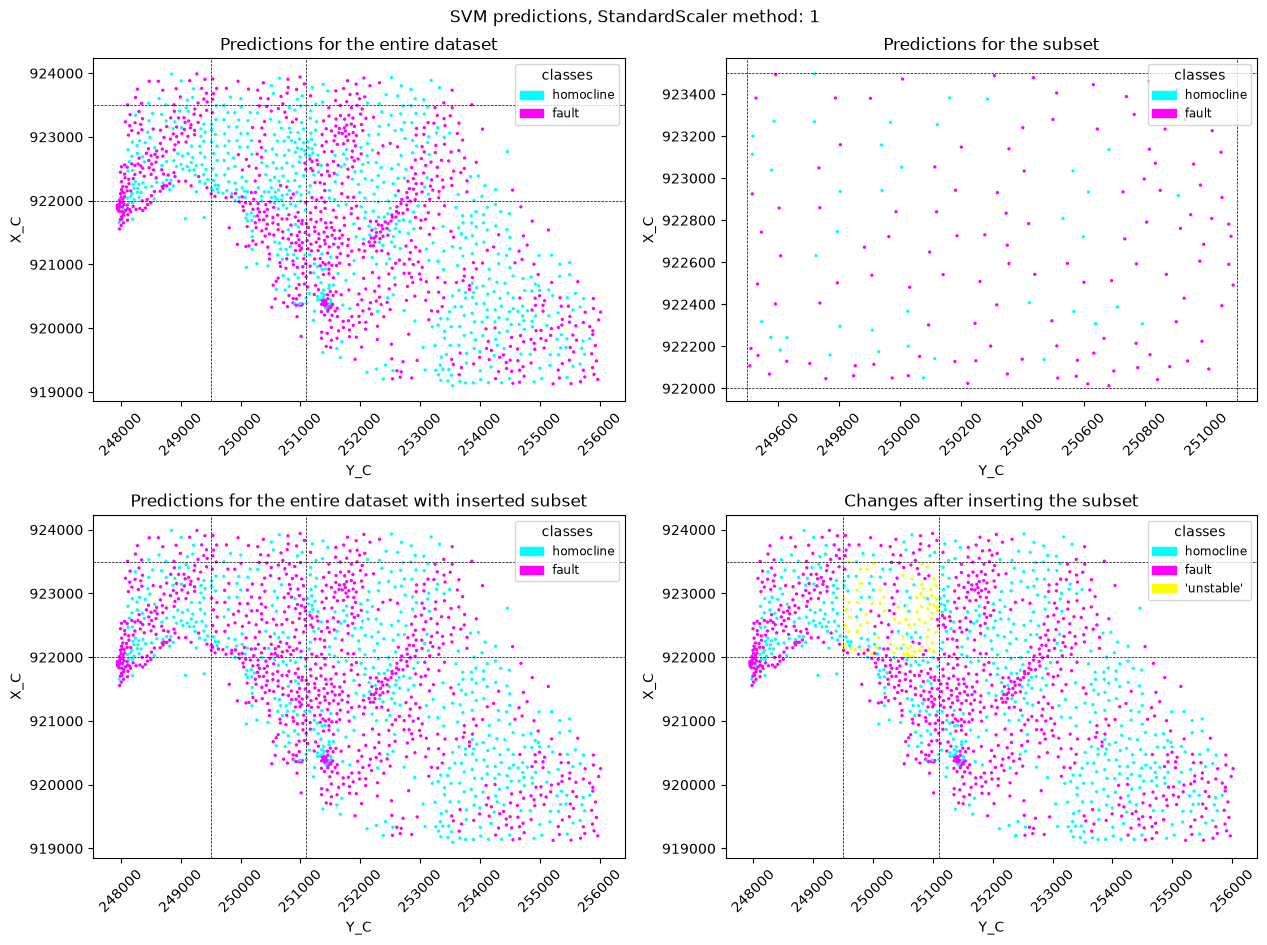

In [50]:
model = SVM

cmap = {0: 'aqua', 1: 'magenta', 2: 'yellow'}
legend_labels_1 = ['homocline', 'fault']
legend_labels_2 = ['homocline', 'fault', '\'unstable\'']
legend_colors_1 = [mpatches.Patch(color=cmap[i], label=legend_labels_1[i]) for i in range(2)]
legend_colors_2 = [mpatches.Patch(color=cmap[i], label=legend_labels_2[i]) for i in range(3)]

fig, ax = plt.subplots(2, 2, figsize=(6.4*2, 4.8*2))

axis = ax.ravel()

axis[0].scatter(results_df["Y_C"], results_df["X_C"], s=2, color=results_df[model].map(cmap))
axis[1].scatter(results_df_subset["Y_C"], results_df_subset["X_C"], s=2, color=results_df_subset[model].map(cmap))
axis[2].scatter(inserted_df["Y_C"], inserted_df["X_C"], s=2, color=inserted_df[model].map(cmap))
axis[3].scatter(changes_df["Y_C"], changes_df["X_C"], s=2, color=changes_df[model].map(cmap))

axis[0].set_title("Predictions for the entire dataset")
axis[1].set_title("Predictions for the subset")
axis[2].set_title("Predictions for the entire dataset with inserted subset")
axis[3].set_title("Changes after inserting the subset")

for i in range(len(axis)):
    axis[i].set_xlabel("Y_C")
    axis[i].set_ylabel("X_C")
    axis[i].tick_params(axis='x', rotation=45)
    axis[i].axhline(y=X_C_LOWER, color='k', linestyle='--', linewidth=0.5)
    axis[i].axhline(y=X_C_UPPER, color='k', linestyle='--', linewidth=0.5)
    axis[i].axvline(x=Y_C_LOWER, color='k', linestyle='--', linewidth=0.5)
    axis[i].axvline(x=Y_C_UPPER, color='k', linestyle='--', linewidth=0.5)
    axis[i].legend(handles=legend_colors_1 if i != 3 else legend_colors_2, loc='upper right', fontsize='small', title='classes')

fig.suptitle(f"{model} predictions, StandardScaler method: {SS_MODE}")

plt.tight_layout()

fig.savefig(f"scaling_method_{SS_MODE}.svg", format="svg", dpi=1200)

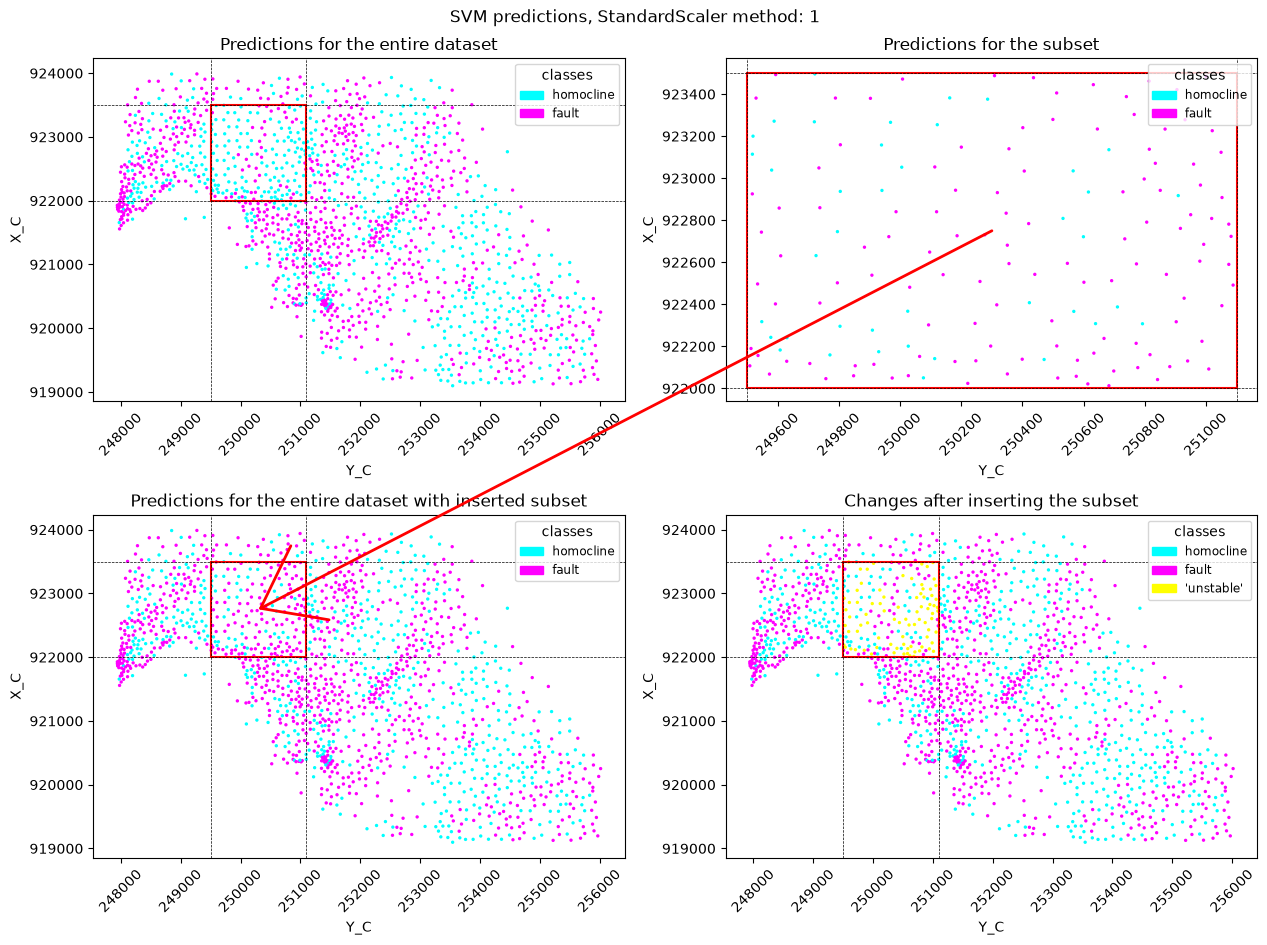

In [51]:
model = SVM

cmap = {0: 'aqua', 1: 'magenta', 2: 'yellow'}
legend_labels_1 = ['homocline', 'fault']
legend_labels_2 = ['homocline', 'fault', '\'unstable\'']
legend_colors_1 = [mpatches.Patch(color=cmap[i], label=legend_labels_1[i]) for i in range(2)]
legend_colors_2 = [mpatches.Patch(color=cmap[i], label=legend_labels_2[i]) for i in range(3)]

fig, ax = plt.subplots(2, 2, figsize=(6.4*2, 4.8*2))

axis = ax.ravel()

axis[0].scatter(results_df["Y_C"], results_df["X_C"], s=2, color=results_df[model].map(cmap))
axis[1].scatter(results_df_subset["Y_C"], results_df_subset["X_C"], s=2, color=results_df_subset[model].map(cmap))
axis[2].scatter(inserted_df["Y_C"], inserted_df["X_C"], s=2, color=inserted_df[model].map(cmap))
axis[3].scatter(changes_df["Y_C"], changes_df["X_C"], s=2, color=changes_df[model].map(cmap))

axis[0].set_title("Predictions for the entire dataset")
axis[1].set_title("Predictions for the subset")
axis[2].set_title("Predictions for the entire dataset with inserted subset")
axis[3].set_title("Changes after inserting the subset")

for i in range(len(axis)):
    axis[i].set_xlabel("Y_C")
    axis[i].set_ylabel("X_C")
    axis[i].tick_params(axis='x', rotation=45)
    axis[i].axhline(y=X_C_LOWER, color='k', linestyle='--', linewidth=0.5)
    axis[i].axhline(y=X_C_UPPER, color='k', linestyle='--', linewidth=0.5)
    axis[i].axvline(x=Y_C_LOWER, color='k', linestyle='--', linewidth=0.5)
    axis[i].axvline(x=Y_C_UPPER, color='k', linestyle='--', linewidth=0.5)
    axis[i].legend(handles=legend_colors_1 if i != 3 else legend_colors_2, loc='upper right', fontsize='small', title='classes')

    rect = mpatches.Rectangle(
        (Y_C_LOWER, X_C_LOWER),
        Y_C_UPPER - Y_C_LOWER,
        X_C_UPPER - X_C_LOWER,
        linewidth=1.5,
        edgecolor='r',
        facecolor='none'
    )
    axis[i].add_patch(rect)


center_y = (Y_C_LOWER + Y_C_UPPER) / 2
center_x = (X_C_LOWER + X_C_UPPER) / 2

ax_start = axis[1]
ax_end = axis[2]

arrow = mpatches.ConnectionPatch(
    xyA=(center_y, center_x),
    xyB=(center_y, center_x),
    coordsA="data",
    coordsB="data",
    axesA=ax_start,
    axesB=ax_end,
    color="red",
    arrowstyle="->,head_length=4,head_width=3",
    linewidth=2
)
fig.add_artist(arrow)
fig.suptitle(f"{model} predictions, StandardScaler method: {SS_MODE}")

plt.tight_layout()

fig.savefig(f"scaling_method_{SS_MODE}_arrow.svg", format="svg", dpi=1200)